In [1]:
import pandas as pd
import numpy as np

In [2]:
heat_link = "https://files.zillowstatic.com/research/public_csvs/market_temp_index/Metro_market_temp_index_uc_sfrcondo_month.csv?t=1764708210"

In [6]:
heat = pd.read_csv(heat_link)

# melt
heat = heat.melt(id_vars=["RegionName"], var_name="Date", value_name="HeatIndex")

# convert Date to datetime, remove error rows
heat["Date"] = pd.to_datetime(heat["Date"], errors='coerce')
heat = heat.dropna(subset=["Date"])

heat_chicago = heat[heat["RegionName"] == "Chicago, IL"].copy()

/var/folders/jd/5wy1jytx2pg8j4jr12tl0k_m0000gq/T/ipykernel_91498/1974170582.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  heat["Date"] = pd.to_datetime(heat["Date"], errors='coerce')


In [7]:
heat_chicago

,RegionName,Date,HeatIndex
3715,"Chicago, IL",2018-01-31,48.0
4643,"Chicago, IL",2018-02-28,49.0
5571,"Chicago, IL",2018-03-31,51.0
6499,"Chicago, IL",2018-04-30,52.0
7427,"Chicago, IL",2018-05-31,51.0
...,...,...,...
86307,"Chicago, IL",2025-06-30,67.0
87235,"Chicago, IL",2025-07-31,65.0
88163,"Chicago, IL",2025-08-31,63.0
89091,"Chicago, IL",2025-09-30,59.0


TypeError: 'NoneType' object is not callable

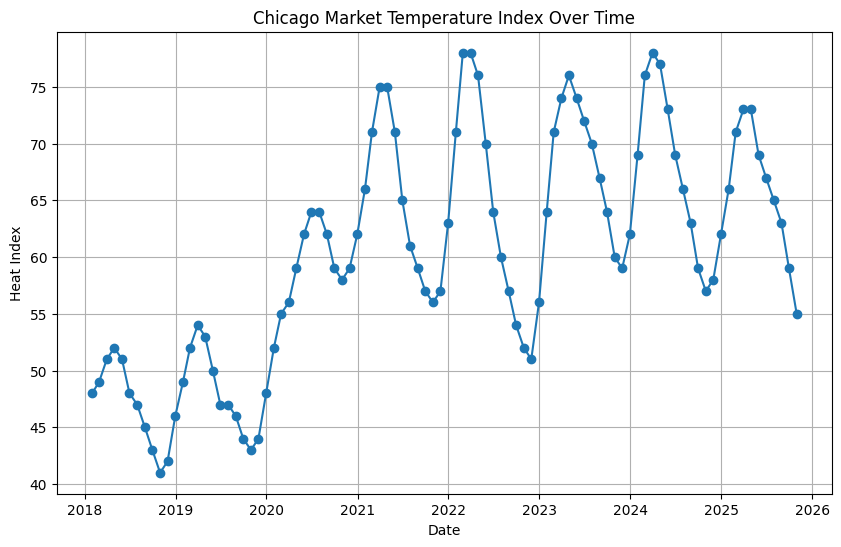

In [10]:
# plot heatindex over time for chicago
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(heat_chicago["Date"], heat_chicago["HeatIndex"], marker='o')
plt.title("Chicago Market Temperature Index Over Time")
plt.xlabel("Date")
plt.ylabel("Heat Index")
plt.grid()(True)
plt.show()